# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [29]:
import seaborn as sns
%matplotlib inline
import pandas as pd

In [30]:
flights = sns.load_dataset('flights') # load dataset from seaborn online repository

In [31]:
tips = sns.load_dataset('tips')

In [32]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [33]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [34]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [35]:
# column type
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [36]:
# automatically identify the numerical columns that are valid for correlation
numerical_cols = tips.select_dtypes(include=['number']).columns
print(numerical_cols)
tips[numerical_cols].corr()

Index(['total_bill', 'tip', 'size'], dtype='object')


,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [37]:
# Convert categorical to numerical: one-hot encoding
tips_onehot = pd.get_dummies(tips, drop_first=True)
print(tips_onehot.columns)
print(tips_onehot.corr())

Index(['total_bill', 'tip', 'size', 'sex_Female', 'smoker_No', 'day_Fri',
       'day_Sat', 'day_Sun', 'time_Dinner'],
      dtype='object')
             total_bill       tip      size  sex_Female  smoker_No   day_Fri  \
total_bill     1.000000  0.675734  0.598315   -0.144877  -0.085721 -0.086168   
tip            0.675734  1.000000  0.489299   -0.088862  -0.005929 -0.055463   
size           0.598315  0.489299  1.000000   -0.086195   0.133178 -0.142184   
sex_Female    -0.144877 -0.088862 -0.086195    1.000000   0.002816  0.071060   
smoker_No     -0.085721 -0.005929  0.133178    0.002816   1.000000 -0.244316   
day_Fri       -0.086168 -0.055463 -0.142184    0.071060  -0.244316  1.000000   
day_Sat        0.054919 -0.002790 -0.041121   -0.053957  -0.155744 -0.216319   
day_Sun        0.122953  0.125114  0.193054   -0.168106   0.181624 -0.195451   
time_Dinner    0.183118  0.121629  0.103411   -0.205231  -0.054921 -0.058159   

              day_Sat   day_Sun  time_Dinner  
total_bill 

In [38]:
# convert categorical to numerical: label encoding
from sklearn.preprocessing import LabelEncoder

tips_encoded = tips.copy()
le = LabelEncoder()

for col in tips.select_dtypes(include=['object', 'category']).columns:
    tips_encoded[col] = le.fit_transform(tips[col])
print(tips_encoded.corr())

            total_bill       tip       sex    smoker       day      time  \
total_bill    1.000000  0.675734  0.144877  0.085721 -0.043550 -0.183118   
tip           0.675734  1.000000  0.088862  0.005929 -0.011548 -0.121629   
sex           0.144877  0.088862  1.000000  0.002816 -0.078292 -0.205231   
smoker        0.085721  0.005929  0.002816  1.000000 -0.282721 -0.054921   
day          -0.043550 -0.011548 -0.078292 -0.282721  1.000000  0.638019   
time         -0.183118 -0.121629 -0.205231 -0.054921  0.638019  1.000000   
size          0.598315  0.489299  0.086195 -0.133178  0.069510 -0.103411   

                size  
total_bill  0.598315  
tip         0.489299  
sex         0.086195  
smoker     -0.133178  
day         0.069510  
time       -0.103411  
size        1.000000  


In [39]:
# Matrix form for correlation data
tips.corr()

ValueError: could not convert string to float: 'No'

<Axes: >

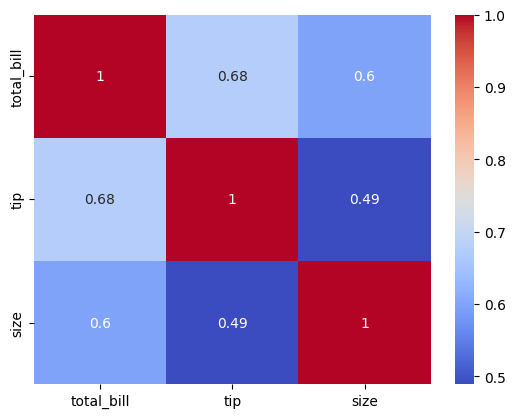

In [40]:
sns.heatmap(tips[numerical_cols].corr(),cmap='coolwarm',annot=True)

<Axes: >

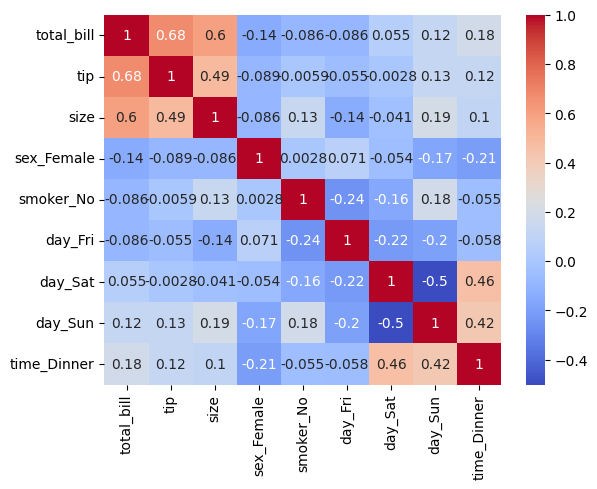

In [41]:
sns.heatmap(tips_onehot.corr(),cmap='coolwarm',annot=True)

In [43]:
tips_encoded

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4
...,...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,0,3
240,27.18,2.00,0,1,1,0,2
241,22.67,2.00,1,1,1,0,2
242,17.82,1.75,1,0,1,0,2


<Axes: >

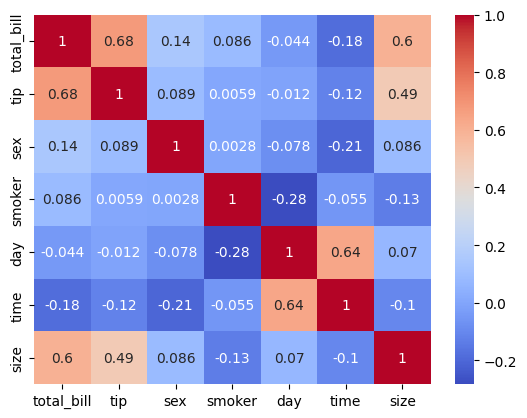

In [44]:
sns.heatmap(tips_encoded.corr(),cmap='coolwarm',annot=True)

Or for the flights data:

## pivot table
The .pivot_table() method in pandas is a powerful tool for summarizing and reshaping your data—like a pivot table in Excel.

In [45]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [46]:
flights.pivot_table(values='passengers',index='month',columns='year')

/tmp/ipykernel_1675878/2056291100.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values='passengers',index='month',columns='year')


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


/tmp/ipykernel_1675878/375637786.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvflights = flights.pivot_table(values='passengers',index='month',columns='year')


<Axes: xlabel='year', ylabel='month'>

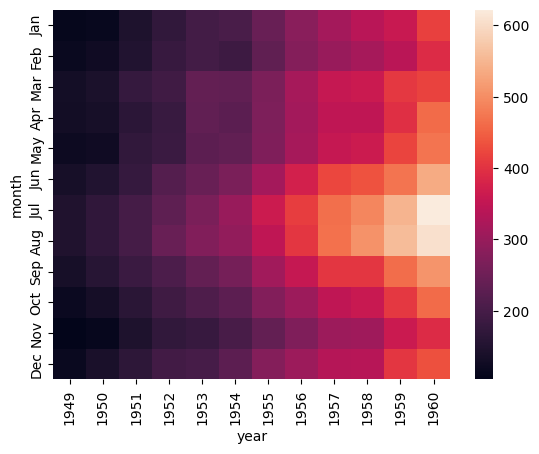

In [47]:
pvflights = flights.pivot_table(values='passengers',index='month',columns='year')
sns.heatmap(pvflights)

In [ ]:
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1)